In [1]:
import torch
from torch import nn
from torchvision import datasets, transforms
import torchvision

from matplotlib import pyplot as plt

import backpack
import copy

from torch_kfac import KFAC

In [2]:
### simple cnn for mnist:

def get_model(BN=True):
    if BN:
        net = nn.Sequential(
            nn.Conv2d(3,64,3, padding = 1),
            nn.BatchNorm2d(64),
            nn.ReLU(), 
            nn.Conv2d(64,64,3, padding = 1),
            nn.BatchNorm2d(64),
            nn.ReLU(), 
            nn.MaxPool2d(2), 
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2), 
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(4096,500),
            nn.ReLU(),
            nn.Linear(500,500),
            nn.ReLU(),
            nn.Linear(500, 10, bias=False)
        )
    else:
        net = nn.Sequential(
            nn.Conv2d(3,64,3, padding = 1),
            nn.ReLU(), 
            nn.Conv2d(64,64,3, padding = 1),
            nn.ReLU(), 
            nn.MaxPool2d(2), 
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2), 
            nn.Conv2d(128, 256, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(4096,500),
            nn.ReLU(),
            nn.Linear(500,500),
            nn.ReLU(),
            nn.Linear(500, 10, bias=False)
        )
    # set freezed attribute of layers:
    if BN:
        freezed_list = [3,10,17]
    else:
        freezed_list = [2,7,12]
        
    for i, layer in enumerate(net.children()):
        if i not in freezed_list:
            setattr(layer, 'freezed', False)
        else:
            setattr(layer, 'freezed', True)

    return net

loss_fn = nn.CrossEntropyLoss()

# backpack.extend(net)
# backpack.extend(loss_fn)

In [3]:
net = get_model(BN=False)
for i, l in enumerate(net):
    print(i, l)

0 Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
1 ReLU()
2 Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
3 ReLU()
4 MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
5 Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
6 ReLU()
7 Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
8 ReLU()
9 MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
10 Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
11 ReLU()
12 Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
13 ReLU()
14 MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
15 Flatten(start_dim=1, end_dim=-1)
16 Linear(in_features=4096, out_features=500, bias=True)
17 ReLU()
18 Linear(in_features=500, out_features=500, bias=True)
19 ReLU()
20 Linear(in_features=500, out_features=10, bias=False)


In [4]:
def prep_cifar10(batch_size=128):

    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    transform_train = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ])

    transform_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ])

    trainset = torchvision.datasets.CIFAR10(
        root='./data', train=True, download=True, transform=transform_train)
    trainloader = torch.utils.data.DataLoader(
        trainset, batch_size=batch_size, shuffle=True, num_workers=2)

    testset = torchvision.datasets.CIFAR10(
        root='./data', train=False, download=True, transform=transform_test)
    testloader = torch.utils.data.DataLoader(
        testset, batch_size=100, shuffle=False, num_workers=2)
    
    return trainloader, testloader

dataloader, testloader = prep_cifar10()

Files already downloaded and verified
Files already downloaded and verified


In [5]:
losses = []
# alpha = 1e-1
# net = get_model()

# for x,y in dataloader:
#     y_pred = net(x)
#     loss = loss_fn(y_pred, y)
#     losses.append(loss.item())
    
#     loss.backward()
    
#     with torch.no_grad():
#         for p in net.parameters():
#             p -= alpha * p.grad
#     net.zero_grad()


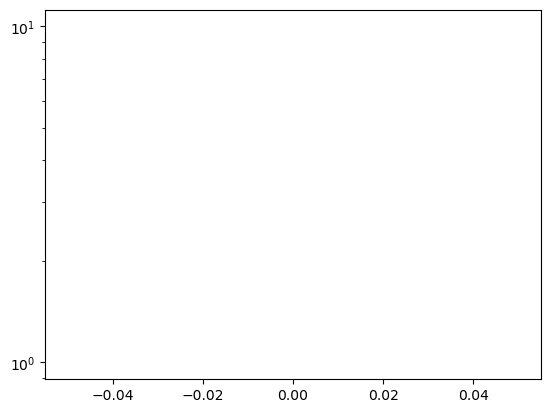

In [6]:
plt.plot(losses)
plt.yscale('log')

## new

In [7]:
BN = False
net_test = get_model(BN)


In [8]:
backpack.extend(net_test)
backpack.extend(loss_fn)

CrossEntropyLoss()

In [9]:
for x,y in dataloader:
    y_pred = net_test(x)
    loss = loss_fn(y_pred, y)
    with backpack.backpack(backpack.extensions.KFAC()):
        loss.backward()
    break



In [10]:
kfacs = []
for i, p in enumerate(net_test.parameters()):
    if i in [6]:
        p_sel_kfac = p.kfac
        p_sel_grad = p.grad
    print(i)
    print([kfac.shape for kfac in p.kfac])
    print('gradshape',p.grad.shape)
    kfacs.append(copy.deepcopy(p.kfac))

0
[torch.Size([64, 64]), torch.Size([27, 27])]
gradshape torch.Size([64, 3, 3, 3])
1
[torch.Size([64, 64])]
gradshape torch.Size([64])
2
[torch.Size([64, 64]), torch.Size([576, 576])]
gradshape torch.Size([64, 64, 3, 3])
3
[torch.Size([64, 64])]
gradshape torch.Size([64])
4
[torch.Size([128, 128]), torch.Size([576, 576])]
gradshape torch.Size([128, 64, 3, 3])
5
[torch.Size([128, 128])]
gradshape torch.Size([128])
6
[torch.Size([128, 128]), torch.Size([1152, 1152])]
gradshape torch.Size([128, 128, 3, 3])
7
[torch.Size([128, 128])]
gradshape torch.Size([128])
8
[torch.Size([256, 256]), torch.Size([1152, 1152])]
gradshape torch.Size([256, 128, 3, 3])
9
[torch.Size([256, 256])]
gradshape torch.Size([256])
10
[torch.Size([256, 256]), torch.Size([2304, 2304])]
gradshape torch.Size([256, 256, 3, 3])
11
[torch.Size([256, 256])]
gradshape torch.Size([256])
12
[torch.Size([500, 500]), torch.Size([4096, 4096])]
gradshape torch.Size([500, 4096])
13
[torch.Size([500, 500])]
gradshape torch.Size([50

In [11]:
def inverse_by_cholesky(tensor, damping):
    damped = tensor + torch.eye(tensor.shape[-1]) * damping
    cholesky = torch.cholesky(damped)
    return torch.cholesky_inverse(cholesky)

In [12]:
def grads_to_mat(grads):
    mat = grads.reshape([grads.shape[0], grads.shape[1]*grads.shape[2]*grads.shape[3]])
    return mat

def mat_to_grads(mat):
    grad = mat.reshape([mat.shape[0],int(mat.shape[1]/9), 3,3])
    return grad

In [13]:
V = grads_to_mat(p_sel_grad)
print(V.shape)
p_sel_kfac[0].shape
p_sel_kfac[1].shape

torch.Size([128, 1152])


torch.Size([1152, 1152])

In [14]:
damping = 1e-1
sen_cov = inverse_by_cholesky(p_sel_kfac[0], damping)
act_cov = inverse_by_cholesky(p_sel_kfac[1], damping)
print(sen_cov.shape)
print(act_cov.shape)

torch.Size([128, 128])
torch.Size([1152, 1152])


/tmp/ipykernel_41196/316044634.py:3: UserWarning: torch.cholesky is deprecated in favor of torch.linalg.cholesky and will be removed in a future PyTorch release.
L = torch.cholesky(A)
should be replaced with
L = torch.linalg.cholesky(A)
and
U = torch.cholesky(A, upper=True)
should be replaced with
U = torch.linalg.cholesky(A).mH().
This transform will produce equivalent results for all valid (symmetric positive definite) inputs. (Triggered internally at /opt/conda/conda-bld/pytorch_1670525493953/work/aten/src/ATen/native/BatchLinearAlgebra.cpp:1615.)
  cholesky = torch.cholesky(damped)


In [15]:
precond_grad_for_one_layer = mat_to_grads(sen_cov @ V @ act_cov)
precond_grad_for_one_layer.shape

torch.Size([128, 128, 3, 3])

In [16]:
#from backpack.utils.kroneckers import apply_kfac_mat_prod as apply_kfac

In [17]:
#precond_grad_for_one_layer = apply_kfac([sen_cov, act_cov], V)

## old


In [18]:
for x,y in dataloader:
    y_pred = net(x)
    loss = loss_fn(y_pred, y)
    with backpack.backpack(backpack.extensions.KFAC()):
        loss.backward()
    break



In [19]:
kfacs = []
for p in net.parameters():
    print([kfac.shape for kfac in p.kfac])
    kfacs.append(copy.deepcopy(p.kfac))

AttributeError: 'Parameter' object has no attribute 'kfac'

In [ ]:
inv_kfacs = []
for kfac in kfacs:
    if len(kfac) == 1:
        inv_kfacs.append(
            torch.linalg.inv(kfac[0] + 1e-3 * torch.eye(kfac[0].shape[0]))
        )
    elif len(kfac) == 2:
        inv_kfacs.append(
            torch.kron(
                torch.linalg.inv(kfac[0] + 1e-3 * torch.eye(kfac[0].shape[0])),
                torch.linalg.inv(kfac[1] + 1e-3 * torch.eye(kfac[1].shape[0]))
            )
        )
    else:
        raise ValueError('kfac has too many dimensions')
    break

In [ ]:
inv_kfacs[0].shape

torch.Size([288, 288])

In [ ]:
for p in net.parameters():
    grad = torch.matmul(inv_kfacs[0], p.grad.flatten()).reshape(p.grad.shape)
    break

torch.Size([32, 1, 3, 3])

In [ ]:
net = get_model()
kfac = KFAC(net, learning_rate=2e-3, damping=1e-2)

In [ ]:
losses = []

for x,y in dataloader:
    net.zero_grad()
    with kfac.track_forward():
        y_pred = net(x)
        loss = loss_fn(y_pred, y)
    
    with kfac.track_backward():
        loss.backward()

    kfac.step(loss = loss)
    losses.append(float(loss))
    print(loss)

/home/leonie/miniconda3/envs/multilevel/lib/python3.10/site-packages/torch/nn/modules/module.py:1117: UserWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  warnings.warn("Using a non-full backward hook when the forward contains multiple autograd Nodes "
/home/leonie/miniconda3/envs/multilevel/lib/python3.10/site-packages/torch_kfac-0.0.1-py3.10.egg/torch_kfac/utils/utils.py:102: UserWarning: torch.cholesky is deprecated in favor of torch.linalg.cholesky and will be removed in a future PyTorch release.
L = torch.cholesky(A)
should be replaced with
L = torch.linalg.cholesky(A)
and
U = torch.cholesky(A, upper=True)
should be replaced with
U = torch.linalg.cholesky(A).mH().
This transform will produce equivalent results for all valid (symmetric positive definite) inputs. (Triggered i

tensor(2.3055, grad_fn=<NllLossBackward0>)
tensor(2.3107, grad_fn=<NllLossBackward0>)
tensor(2.3029, grad_fn=<NllLossBackward0>)
tensor(2.3032, grad_fn=<NllLossBackward0>)
tensor(2.3071, grad_fn=<NllLossBackward0>)
tensor(2.3017, grad_fn=<NllLossBackward0>)
tensor(2.2920, grad_fn=<NllLossBackward0>)
tensor(2.3052, grad_fn=<NllLossBackward0>)
tensor(2.2991, grad_fn=<NllLossBackward0>)
tensor(2.3044, grad_fn=<NllLossBackward0>)
tensor(2.3056, grad_fn=<NllLossBackward0>)
tensor(2.3089, grad_fn=<NllLossBackward0>)
tensor(2.3052, grad_fn=<NllLossBackward0>)
tensor(2.3012, grad_fn=<NllLossBackward0>)
tensor(2.3061, grad_fn=<NllLossBackward0>)
tensor(2.2944, grad_fn=<NllLossBackward0>)
tensor(2.3011, grad_fn=<NllLossBackward0>)
tensor(2.3013, grad_fn=<NllLossBackward0>)
tensor(2.3018, grad_fn=<NllLossBackward0>)
tensor(2.3001, grad_fn=<NllLossBackward0>)
tensor(2.2993, grad_fn=<NllLossBackward0>)
tensor(2.3022, grad_fn=<NllLossBackward0>)
tensor(2.3064, grad_fn=<NllLossBackward0>)
tensor(2.29

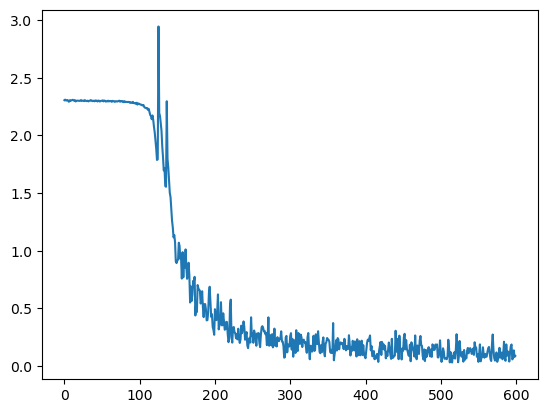

In [ ]:
plt.plot(losses)

In [ ]:
kfac.update_cov()
nat_grads = kfac._get_raw_updates()

In [ ]:
print(nat_grads[0][0][0].shape)
print(nat_grads[1][0][0].shape)
print(nat_grads[2][0][0].shape)
print(nat_grads[3][0][0].shape)
print(nat_grads[4][0][0].shape)
print(nat_grads[5][0][0].shape)
print(nat_grads[6][0][0].shape)


torch.Size([32, 1, 3, 3])
torch.Size([64, 32, 3, 3])
torch.Size([128, 64, 3, 3])
torch.Size([256, 128, 3, 3])
torch.Size([256, 256, 3, 3])
torch.Size([128, 2304])
torch.Size([10, 128])


IndexError: tuple index out of range

In [ ]:
print(nat_grads[0][0][1].shape) 
# first index is blockindex
# second index:1 gives (conv/linear)fisherblock, 0 gives tuple of:
# third index: 0 gives shape of conv kernels/weights, 1 gives shape of biases

torch.Size([32])


In [ ]:
nat_grads[0][0][0]

tensor([[[[ 5.6298e+04,  4.0685e+04,  1.8748e+04],
          [ 7.9311e+04,  9.0063e+04,  3.6633e+04],
          [ 8.9627e+04,  1.1282e+05,  9.3271e+04]],

         [[ 3.6133e+04,  1.1858e+04, -2.6482e+04],
          [ 4.7675e+04,  4.9986e+04, -1.1821e+04],
          [ 5.4031e+04,  6.8562e+04,  4.2306e+04]],

         [[ 4.4872e+04,  2.6170e+04,  7.4259e+03],
          [ 5.7294e+04,  7.0024e+04,  2.4241e+04],
          [ 6.8965e+04,  9.5430e+04,  7.4031e+04]]],


        [[[-1.3573e+05, -1.1801e+05, -1.2690e+05],
          [-1.5124e+05, -1.5127e+05, -1.5237e+05],
          [-1.3401e+05, -1.4628e+05, -1.4602e+05]],

         [[-1.3729e+05, -1.1557e+05, -1.3689e+05],
          [-1.5308e+05, -1.5208e+05, -1.5706e+05],
          [-1.3495e+05, -1.5469e+05, -1.5467e+05]],

         [[-1.0436e+05, -7.6594e+04, -9.0621e+04],
          [-1.2050e+05, -1.1980e+05, -1.1673e+05],
          [-1.1300e+05, -1.2813e+05, -1.2252e+05]]],


        [[[-8.8938e+03,  1.9425e+03,  3.0215e+04],
          [-4.4